# Recitation 1 (MIMIC-IV structure and data exploration)

**Advanced Data Science · NYU Paris · 2026 · Week 1 (1.5h)**

Today's lecture went through the ways real data breaks a model: the **labels are noisy**,
the **features are wrong**, values are **missing**, the classes are **imbalanced**, the
world **shifts**, models learn **shortcuts**, and information **leaks** across the split.
This notebook is where you check whether any of that is true of an actual dataset.

We use the **MIMIC-IV Clinical Database Demo v2.2**: 100 real ICU patients from Beth
Israel Deaconess Medical Center, released *open access* (no credentialing required).
The full MIMIC-IV needs CITI training and a data use agreement (the demo has the
identical schema, so everything you learn here transfers).

## What you should be able to do at the end

1. Explain what one row means in any MIMIC table, and which key joins it to the others.
2. Say where a label came from, and name a case where it is wrong.
3. Find impossible values and mixed units before they reach a model.
4. Quantify missingness, class imbalance, and sampling irregularity.
5. Spot at least two ways this dataset will happily leak the answer to a model.
6. Build a train/test split that does not cheat.

## Ground rules

- No re-identification attempts, ever. Dates are shifted into the future by design and
  ages above 89 are aggregated (leave it that way).
- Do not upload any of this data to an external service (yes, including LLM APIs).

> **Exercise** cells are for you. Cells without an exercise are demonstrations (read the
> code, do not just run it).

---
## 0. Setup

The download is ~16 MB and is cached, so you only pay for it once.

- Dataset: <https://physionet.org/content/mimic-iv-demo/2.2/>
- Documentation: <https://mimic.mit.edu/docs/iv/>

Every table is documented column by column at
`https://mimic.mit.edu/docs/iv/modules/{hosp,icu}/<table>.html` (for example
[`patients`](https://mimic.mit.edu/docs/iv/modules/hosp/patients.html) and
[`labevents`](https://mimic.mit.edu/docs/iv/modules/hosp/labevents.html)).
Look a column up before you guess what it means; that habit is most of section 2.

In [1]:
from __future__ import annotations

import io
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

MIMIC_URL = (
    "https://physionet.org/static/published-projects/mimic-iv-demo/"
    "mimic-iv-clinical-database-demo-2.2.zip"
)

# Repo-root/data, so later sessions can reuse the same download.
DATA_DIR = Path("../data").resolve()
MIMIC_DIR = DATA_DIR / "mimic-iv-clinical-database-demo-2.2"

In [2]:
def fetch_mimic_demo() -> Path:
    """Download and extract the MIMIC-IV demo once; return its directory."""
    if MIMIC_DIR.exists():
        print(f"already present: {MIMIC_DIR}")
        return MIMIC_DIR

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f"downloading {MIMIC_URL} ...")
    with urllib.request.urlopen(MIMIC_URL) as response:
        payload = response.read()
    print(f"  {len(payload) / 1e6:.1f} MB, extracting to {DATA_DIR}")
    with zipfile.ZipFile(io.BytesIO(payload)) as archive:
        archive.extractall(DATA_DIR)
    return MIMIC_DIR


fetch_mimic_demo()

already present: /home/paul/Documents/Cours/NYU_Paris2026/data/mimic-iv-clinical-database-demo-2.2


PosixPath('/home/paul/Documents/Cours/NYU_Paris2026/data/mimic-iv-clinical-database-demo-2.2')

In [3]:
def load(table: str, **kwargs) -> pd.DataFrame:
    """Load a MIMIC table, e.g. load("hosp/admissions") or load("icu/icustays")."""
    return pd.read_csv(MIMIC_DIR / f"{table}.csv.gz", **kwargs)


# What is actually in the box?
for module in ("hosp", "icu"):
    files = sorted(p.name.removesuffix(".csv.gz") for p in (MIMIC_DIR / module).glob("*.csv.gz"))
    print(f"{module}/ ({len(files)} tables)")
    print("   ", ", ".join(files), "\n")

hosp/ (22 tables)
    admissions, d_hcpcs, d_icd_diagnoses, d_icd_procedures, d_labitems, diagnoses_icd, drgcodes, emar, emar_detail, hcpcsevents, labevents, microbiologyevents, omr, patients, pharmacy, poe, poe_detail, prescriptions, procedures_icd, provider, services, transfers 

icu/ (9 tables)
    caregiver, chartevents, d_items, datetimeevents, icustays, ingredientevents, inputevents, outputevents, procedureevents 



Two modules:

- **`hosp/`**, everything the hospital records: admissions, labs, diagnoses,
  prescriptions, orders. Hospital-wide, coarse time resolution.
- **`icu/`**, the ICU monitoring system: charted vitals, infusions, procedures.
  Only for patients who went to the ICU, minute-level resolution.

Tables named `d_*` are **dictionaries** (`d_labitems`, `d_icd_diagnoses`, `d_items`):
they map opaque integer/string codes to human-readable labels. You will join against
them constantly.

---
## 1. What is one row?

The single most important question about any table. Let's ask it three times.

In [4]:
patients = load("hosp/patients")
admissions = load("hosp/admissions", parse_dates=["admittime", "dischtime", "deathtime", "edregtime", "edouttime"])
icustays = load("icu/icustays", parse_dates=["intime", "outtime"])

for name, df in [("patients", patients), ("admissions", admissions), ("icustays", icustays)]:
    print(f"{name:12s} {df.shape[0]:6d} rows x {df.shape[1]:2d} cols")

patients        100 rows x  6 cols
admissions      275 rows x 16 cols
icustays        140 rows x  8 cols


In [5]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


`patients`: one row per **person**. Note the de-identification scheme (there is no real
date of birth). Instead:

- `anchor_age`, the patient's age in `anchor_year`
- `anchor_year`, a *shifted* year, not the real one
- `anchor_year_group`, the real 3-year window the stay falls in (this is the only
  honest calendar information you get)
- `dod`, date of death, taken from the hospital record **and** the Massachusetts State
  Registry of Vital Records. Date only, no time.

So `age at admission = anchor_age + (admittime.year - anchor_year)`.

The [`patients` documentation](https://mimic.mit.edu/docs/iv/modules/hosp/patients.html)
adds the part that matters for `dod`: out-of-hospital mortality is linked only **up to one
year after discharge**, and anything later is censored. So a missing `dod` is not evidence
that the patient survived (it may only mean the follow-up window ran out).

In [6]:
admissions.head(3)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaT,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaT,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaT,NaT,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaT,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0


In [7]:
icustays.head(3)

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685


### The key hierarchy

```mermaid
graph LR
    P["patients<br/>subject_id"] --> A["admissions<br/>subject_id, hadm_id"]
    A --> I["icustays<br/>subject_id, hadm_id, stay_id"]
    A --> L["labevents<br/>subject_id, hadm_id"]
    A --> D["diagnoses_icd<br/>subject_id, hadm_id"]
    I --> C["chartevents<br/>subject_id, hadm_id, stay_id"]
```

- `subject_id`, one **patient** (can have many admissions)
- `hadm_id`, one **hospital admission** (can have several ICU stays)
- `stay_id`, one **ICU stay**

Get this wrong and you either lose rows or multiply them. Check it yourself:

In [8]:
print("patients          :", patients.subject_id.nunique())
print("admissions        :", len(admissions), "rows,", admissions.hadm_id.nunique(), "unique hadm_id")
print("  patients w/ >1 admission:", (admissions.groupby("subject_id").size() > 1).sum())
print("icu stays         :", len(icustays), "rows,", icustays.stay_id.nunique(), "unique stay_id")
print("  admissions w/ >1 icu stay:", (icustays.groupby("hadm_id").size() > 1).sum())
print("  admissions w/ 0 icu stay :", admissions.hadm_id.nunique() - icustays.hadm_id.nunique())

patients          : 100
admissions        : 275 rows, 275 unique hadm_id
  patients w/ >1 admission: 48
icu stays         : 140 rows, 140 unique stay_id
  admissions w/ >1 icu stay: 9
  admissions w/ 0 icu stay : 147


> **Exercise 1.** How many admissions does the busiest patient have? Print their
> `subject_id`, their number of admissions, and the time span between their first
> and last `admittime`.
>
> Then answer in one sentence: if you split train/test **by admission**, what happens
> to this patient?

In [9]:
# Your code here


---
## 2. Noise: the label is a proxy

The lecture's first claim was that a label is not the truth (it is the output of a
*measurement process*, and you cannot interpret it without knowing what that process did).

Here the label is `hospital_expire_flag`, and the process that produced it answers a
narrower question than the one you probably think you are asking: **did this patient die
in this hospital, during this admission?**


In [10]:
print(admissions.discharge_location.value_counts(dropna=False).to_string())

discharge_location
HOME HEALTH CARE                76
HOME                            72
NaN                             42
SKILLED NURSING FACILITY        36
DIED                            15
REHAB                           13
CHRONIC/LONG TERM ACUTE CARE     9
HOSPICE                          5
AGAINST ADVICE                   4
PSYCH FACILITY                   2
ACUTE HOSPITAL                   1


In [11]:
checks = pd.DataFrame(
    {
        "flag_set": admissions.hospital_expire_flag.astype(bool),
        "deathtime_present": admissions.deathtime.notna(),
        "to_hospice": admissions.discharge_location.eq("HOSPICE"),
    }
)

print(pd.crosstab(checks.deathtime_present, checks.flag_set), "\n")
print(pd.crosstab(checks.to_hospice, checks.flag_set))

flag_set           False  True 
deathtime_present              
False                260      0
True                   0     15 

flag_set    False  True 
to_hospice              
False         255     15
True            5      0


`deathtime` and `hospital_expire_flag` agree perfectly (one consistency check passed, and
worth running on any label you are handed).

The hospice rows are the interesting ones. A patient discharged to hospice is, in nearly
every case, days from death. The label says **survived**.

Notice the *direction*. This error can only ever turn a death into a survival, never the
reverse (it is the **asymmetric** noise from the lecture, the kind that does not average
out). A model trained on this label learns to under-predict death for precisely the
patients whose outcome is least in doubt. Nothing in the table tells you this is
happening; you have to know how the label was made.

Two more things this label is not:

- It is not 30-day mortality. A patient who dies six days after discharge is a `0`.
- It is not comparable across hospitals. One that transfers dying patients out scores
  better on it than one that keeps them.

There is no fix in code here. The fix is to write down, in the paper, which question your
label actually answers.


> **Exercise 2.** The label says 15 patients died. `patients.dod` disagrees.
>
> 1. Count how many patients have a `dod`, and how many were ever flagged with
>    `hospital_expire_flag == 1`. They are not the same number.
> 2. For the patients who died but were *never* flagged, how long after their last
>    discharge did they die? How many died within 30 days?
> 3. Build the 30-day label (died in hospital **or** within 30 days of discharge) and
>    compare its base rate with the in-hospital one.
>
> Then answer in a sentence or two: you were asked to predict "mortality". Which of those
> two numbers is your label, which one did the question mean, and what does the one-year
> censoring described in the [documentation](https://mimic.mit.edu/docs/iv/modules/hosp/patients.html)
> stop you from building at all?

In [ ]:
# Your code here

*Your answer here (double-click to edit):*

---
## 3. Errors in the features

The lecture opened this section with three lines: `min`/`max` for impossible values, a
histogram for mixed units, and a group-by for the same measurement recorded two ways.
Run them on real data before you run anything else.


> **Exercise 3 (three predictions).** One before each cell below. Write the answer down
> *before* you run the cell: a prediction you did not commit to is not a prediction, and
> what matters in this section is which of them surprises you.
>
> **3a.** The next cell prints `count`, `min` and `max` of charted heart rate across every
> ICU stay in the demo. What do you expect `min` and `max` to be?

*Your prediction:*  min = , max =

In [12]:
chartevents = load("icu/chartevents", parse_dates=["charttime"])
d_items = load("icu/d_items")

HEART_RATE = 220045  # itemid, see d_items
hr_raw = chartevents.loc[chartevents.itemid == HEART_RATE, "valuenum"]

print(hr_raw.agg(["count", "min", "max"]).to_string())
print("\nvalues at or below zero:", int((hr_raw <= 0).sum()))

count    13913.0
min          0.0
max        200.0

values at or below zero: 3


A heart rate of 0 is not bradycardia (it is a lead that came off, or a monitor between
patients). Three rows out of ~14 000: too few to move a mean, more than enough to break a
`min` feature, and completely invisible unless you look.

> **3a, follow-up.** You build a feature `hr_min_24h` (the lowest charted heart rate in
> the first 24 hours) and it turns out to be a strong predictor of death. Given the
> minimum you just saw, what might that feature actually be measuring?


*Your prediction:*


> **3b.** MIMIC records admission weight under two `itemid`s (one in kilograms, one in
> pounds). The next two cells pool them into one column and plot it.
>
> Sketch the histogram you expect before you look. How many peaks, and roughly where?

*Your prediction:*


In [13]:
weight_items = d_items[d_items.label.str.startswith("Admission Weight", na=False)]
print(weight_items[["itemid", "label", "unitname"]].to_string(index=False), "\n")

weights = chartevents[chartevents.itemid.isin(weight_items.itemid)]
print(weights.groupby("itemid").valuenum.agg(["count", "min", "median", "max"]).to_string())

 itemid                   label unitname
 226531 Admission Weight (lbs.)      NaN
 226512   Admission Weight (Kg)       kg 

        count   min  median    max
itemid                            
226512    129  39.4    77.4  143.0
226531    236   0.0   172.5  314.6


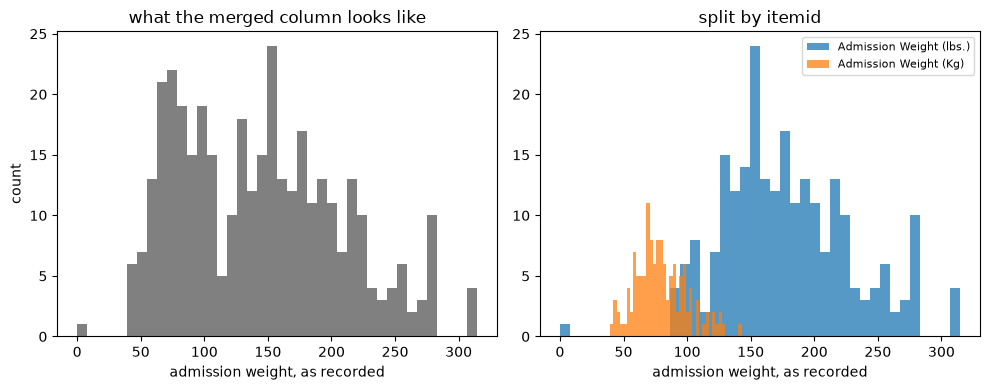

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

axes[0].hist(weights.valuenum.dropna(), bins=40, color="grey")
axes[0].set_title("what the merged column looks like")

for itemid, label in weight_items.set_index("itemid").label.items():
    axes[1].hist(weights.loc[weights.itemid == itemid, "valuenum"].dropna(),
                 bins=40, alpha=0.75, label=label)
axes[1].set_title("split by itemid")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("admission weight, as recorded")
axes[0].set_ylabel("count")
plt.tight_layout()

The kg/lb example from the lecture, in the wild, and notice that the left-hand panel does
**not** look obviously broken. The lecture's figure had two clean humps because it was
drawn that way; here the two distributions are wide enough, and the sample small enough,
that the merged column just looks like a lumpy weight distribution. Plenty of people would
scroll past it.

MIMIC is careful (it keeps the two in different `itemid`s, and only one of them declares a
`unitname`). But the moment you select rows by label text, or concatenate two sites'
extracts, the distinction is gone. Note also the minimum of `0.0` on the lbs item: a
sentinel, not a patient.

The general rule: **a number is meaningless without its unit, and the unit lives in a
different column.** Carry the pair, or convert immediately and record that you did.

> **3b, follow-up.** The merged panel does not look obviously broken. Two questions:
> which check *would* have caught it, and would that check still have been necessary if
> the two units had been kilograms and **grams** rather than kilograms and pounds?


*Your prediction:*


> **3c.** The next cell counts, for each of the 498 distinct lab tests in the demo, how
> many different `valueuom` strings it was recorded under.
>
> How many tests do you expect to come back with more than one unit? And before you run
> it: is a test recorded under two unit strings necessarily a bug?

*Your prediction:*


In [15]:
labevents = load("hosp/labevents", parse_dates=["charttime"], low_memory=False)
d_labitems = load("hosp/d_labitems")
labs = labevents.merge(
    d_labitems[["itemid", "label", "fluid", "category"]], on="itemid", how="left"
)

# The same test, recorded under more than one unit string
units = labs.groupby(["itemid", "label"]).valueuom.nunique()
print(units[units > 1].to_string(), "\n")

D_DIMER = 50915
print(labs[labs.itemid == D_DIMER].groupby("valueuom").valuenum.agg(["count", "median"]).to_string())

itemid  label                   
50915   D-Dimer                     2
51099   Protein/Creatinine Ratio    2
51249   MCHC                        2
51654   HIV 1 Viral Load            2 

           count  median
valueuom                
ng/mL          4  1516.5
ng/mL FEU      3  1179.0


Four tests are recorded under two different unit strings, and they are not all the same
kind of problem:

- **MCHC** in `%` and in `g/dL`, the same number, two names. Harmless once you notice.
- **D-Dimer** in `ng/mL` and `ng/mL FEU`, *not* the same number. FEU (fibrinogen
  equivalent units) runs about twice the DDU scale, so pooling them shifts values by a
  factor of two, in a test used to rule out clots.

`groupby("itemid").valuenum.median()` gives you an answer for either. Only
`groupby(["itemid", "valueuom"])` tells you whether to trust it.

Two more from the lecture that do not fit in one line, and that you should assume are
present here:

- **Copy-forward**, the same "current" value repeated across days because someone cloned
  yesterday's note. Look for runs of identical values at implausibly regular intervals.
- **Timestamps** (`charttime` is when the value was *charted*, which is not when it was
  *measured*). In `labevents` you also get `storetime`; the gap between them is sometimes
  hours, and a feature window built on the wrong one leaks.

> **3c, follow-up.** `labs.groupby("itemid").valuenum.median()` runs without error on
> D-Dimer and returns a single number. What is that number the median *of*, and what
> would you have to write instead?


---
## 4. Missingness

Column-level missingness first (the cheapest diagnostic there is).

In [16]:
def missingness(df: pd.DataFrame):
    """Fraction missing per column, worst first."""
    frac = df.isna().mean().sort_values(ascending=False)
    return frac[frac > 0].to_frame("missing_frac")


missingness(admissions)

,missing_frac
deathtime,0.945455
edouttime,0.338182
edregtime,0.338182
discharge_location,0.152727
marital_status,0.043636


`deathtime` is ~95% missing. That is not a data quality problem (it is the base rate
of in-hospital mortality). **Missingness and semantics are entangled**; you cannot decide
what to do with a NaN without knowing what it means.

Now the interesting case: labs. A lab value is missing because **nobody ordered the test**.

In [17]:
# `labs` was built in section 3
print(f"{len(labs):,} lab measurements, {labs.itemid.nunique()} distinct tests")

# How often is each test ordered, as a fraction of admissions?
coverage = (
    labs.groupby("label")["hadm_id"].nunique().div(admissions.hadm_id.nunique()).sort_values(ascending=False)
)
coverage.head(15).to_frame("frac_of_admissions_with_test")

107,727 lab measurements, 498 distinct tests


,frac_of_admissions_with_test
label,
Sodium,0.909091
Urea Nitrogen,0.909091
Potassium,0.909091
Creatinine,0.909091
Chloride,0.909091
Platelet Count,0.901818
Hematocrit,0.901818
Anion Gap,0.894545
Bicarbonate,0.894545


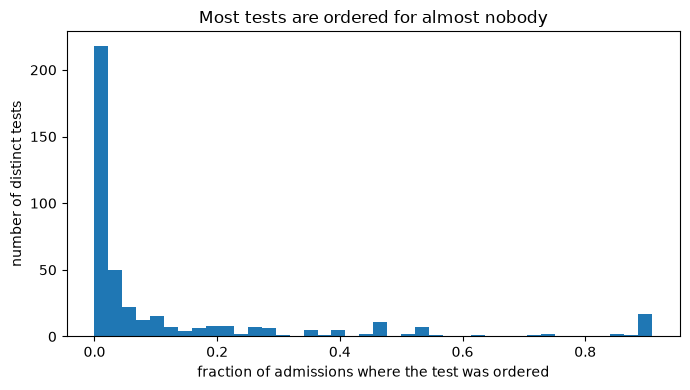

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(coverage.values, bins=40)
ax.set_xlabel("fraction of admissions where the test was ordered")
ax.set_ylabel("number of distinct tests")
ax.set_title("Most tests are ordered for almost nobody")
plt.tight_layout()

This is the shape you should expect from every EHR: a handful of near-universal tests
(the basic metabolic panel, the CBC) and a very long tail of tests ordered for a specific
suspicion.

Build a patient × test matrix from this and it is >95% empty, and the emptiness is
**MNAR**: the test is missing precisely because the clinician judged it unnecessary.

> **Exercise 4.** Pick a test from the long tail, ordered for between 5% and 30% of
> admissions (`coverage` will help). For admissions **with** that test versus **without**
> it, compare the in-hospital mortality rate (`admissions.hospital_expire_flag`).
>
> If they differ: is the *presence of the measurement* informative? Would you feed a
> `has_test` indicator to a model? What could go wrong?

In [19]:
# Your code here

---
## 5. Class imbalance

Two standard prediction targets, straight from the admissions table.

In [20]:
mortality = admissions.hospital_expire_flag.mean()
print(f"in-hospital mortality: {mortality:.1%}  ({admissions.hospital_expire_flag.sum()} / {len(admissions)})")

# 30-day readmission: does the same patient come back within 30 days of discharge?
adm = admissions.sort_values(["subject_id", "admittime"]).copy()
adm["next_admittime"] = adm.groupby("subject_id")["admittime"].shift(-1)
adm["days_to_next"] = (adm.next_admittime - adm.dischtime).dt.total_seconds() / 86400
adm["readmit_30d"] = (adm.days_to_next <= 30) & (adm.days_to_next >= 0)

print(f"30-day readmission  : {adm.readmit_30d.mean():.1%}  ({adm.readmit_30d.sum()} / {len(adm)})")
print(f"\naccuracy of a model that always predicts 'no death': {1 - mortality:.1%}")

in-hospital mortality: 5.5%  (15 / 275)
30-day readmission  : 19.3%  (53 / 275)

accuracy of a model that always predicts 'no death': 94.5%


An "always no" classifier gets ~95% accuracy on mortality. This is why **accuracy is
banned in this course** (we use PR curves, calibration and clinical utility in Weeks 3–4).

Note also that the demo cohort is *all ICU patients*, so these base rates are far higher
than in a general hospital population. The demo is a **biased sample** of MIMIC, which is
itself a biased sample of one Boston hospital. Never quote a base rate without its cohort.

> **Exercise 5.** The readmission definition above has at least two defects. Find them.
>
> Hints to check: what happens to patients who *died* during the admission? What happens
> to the last admission of every patient? What would the number look like if the demo
> contained only a 100-patient sample of a much larger hospital?

*Your answer here (double-click to edit):*

1.
2.

---
## 6. Irregular sampling

Vitals and labs are not a time series on a fixed grid. They are events, recorded when
someone decided to look.

In [21]:
# `chartevents`, `d_items` and HEART_RATE all come from section 3
hr = chartevents[chartevents.itemid == HEART_RATE].merge(
    icustays[["stay_id", "intime"]], on="stay_id", how="left"
)
hr["hours_since_admit"] = (hr.charttime - hr.intime).dt.total_seconds() / 3600

print(d_items.loc[d_items.itemid == HEART_RATE, ["label", "unitname", "lownormalvalue", "highnormalvalue"]])
print(f"\n{len(hr):,} heart-rate measurements across {hr.stay_id.nunique()} ICU stays")

           label unitname  lownormalvalue  highnormalvalue
2577  Heart Rate      bpm             NaN              NaN

13,913 heart-rate measurements across 140 ICU stays


count    13773.0
mean        52.5
std         30.8
min          1.0
50%         60.0
90%         60.0
99%        109.3
max       2626.0
Name: charttime, dtype: float64


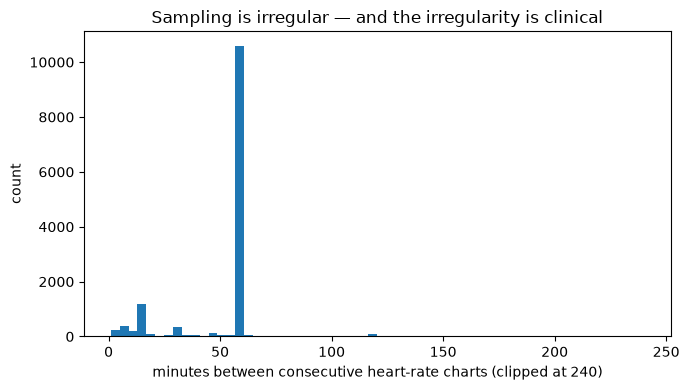

In [22]:
# Time between consecutive measurements, per stay
gaps = hr.sort_values(["stay_id", "charttime"]).groupby("stay_id")["charttime"].diff().dt.total_seconds() / 60

print(gaps.describe(percentiles=[0.5, 0.9, 0.99]).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gaps.dropna().clip(upper=240), bins=60)
ax.set_xlabel("minutes between consecutive heart-rate charts (clipped at 240)")
ax.set_ylabel("count")
ax.set_title("Sampling is irregular, and the irregularity is clinical")
plt.tight_layout()

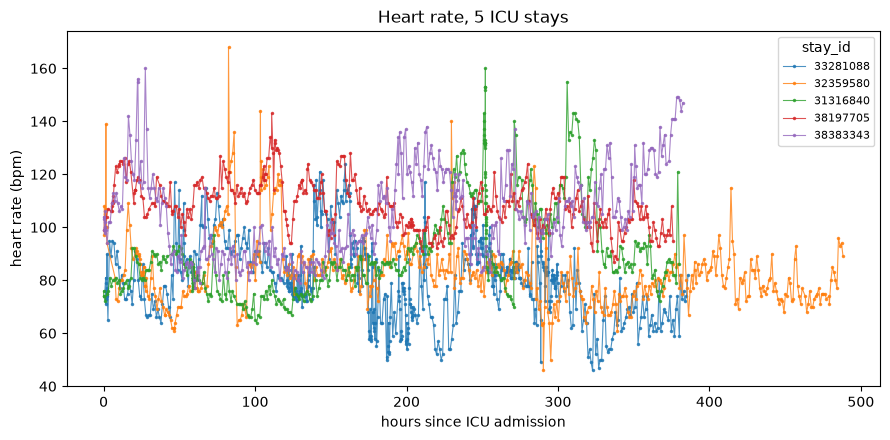

In [23]:
# Five example stays: the same variable, wildly different observation patterns
examples = hr.stay_id.value_counts().index[:5]

fig, ax = plt.subplots(figsize=(9, 4.5))
for stay_id in examples:
    sub = hr[hr.stay_id == stay_id].sort_values("charttime")
    ax.plot(sub.hours_since_admit, sub.valuenum, marker=".", ms=3, lw=0.8, alpha=0.8, label=str(stay_id))
ax.set_xlabel("hours since ICU admission")
ax.set_ylabel("heart rate (bpm)")
ax.set_title("Heart rate, 5 ICU stays")
ax.legend(fontsize=8, title="stay_id")
plt.tight_layout()

A sicker patient is measured more often. So **measurement frequency is itself a
predictor**, and one that will not exist in the same form at deployment time, or at
another hospital with a different nurse-to-patient ratio.

We handle this properly in Weeks 5–6 (irregular time series, GRU-D).

> **Exercise 6.** For each ICU stay, compute the number of heart-rate measurements per
> hour of stay (`icustays.los` is in days). Then check whether that rate is associated
> with in-hospital mortality (a boxplot by `hospital_expire_flag` is enough).
>
> With ~100 patients, is what you see evidence, or noise? Say why.

In [24]:
# Your code here

---
## 7. Two traps

### 7.1 The ICD-version trap

The US switched from ICD-9 to ICD-10 on 1 October 2015. MIMIC-IV spans the transition and
contains **both**, distinguished only by `icd_version`.

In [25]:
diagnoses = load("hosp/diagnoses_icd")
d_icd = load("hosp/d_icd_diagnoses")

print(diagnoses.icd_version.value_counts().to_string(), "\n")

# The naive thing everybody does first:
naive_top = diagnoses.icd_code.value_counts().head(5)
print("top codes, ignoring icd_version:")
print(naive_top.to_string())

icd_version
10    2313
9     2193 

top codes, ignoring icd_version:
icd_code
4019    68
E785    57
2724    55
E039    47
Z794    37


In [26]:
# The same string means different things in the two versions.
collisions = (
    diagnoses.groupby("icd_code")["icd_version"].nunique().loc[lambda s: s > 1].index
)
print(f"{len(collisions)} code strings appear under BOTH ICD-9 and ICD-10\n")

example = collisions[0]
print(d_icd[d_icd.icd_code == example][["icd_version", "long_title"]].to_string(index=False))

2 code strings appear under BOTH ICD-9 and ICD-10

 icd_version                                                             long_title
           9                       Accidental fall on or from other stairs or steps
          10 Other disorders of plasma-protein metabolism, not elsewhere classified


A fall and a metabolic disorder, same string, two eras. `groupby("icd_code")` silently merged them.
**Always join on the pair `(icd_code, icd_version)`.**

Mapping between versions is genuinely hard: the official GEMs crosswalks are
many-to-many, and there is no lossless answer. In practice you either restrict to one
era, or roll up to a coarse grouping (CCS / Elixhauser / Charlson).

In [27]:
# Done correctly:
top = (
    diagnoses.merge(d_icd, on=["icd_code", "icd_version"], how="left")
    .groupby(["icd_code", "icd_version", "long_title"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
top.to_frame("n")

,,,n
icd_code,icd_version,long_title,
4019,9,Unspecified essential hypertension,68
E785,10,"Hyperlipidemia, unspecified",57
2724,9,Other and unspecified hyperlipidemia,55
E039,10,"Hypothyroidism, unspecified",47
Z794,10,Long term (current) use of insulin,37
Z87891,10,Personal history of nicotine dependence,35
42731,9,Atrial fibrillation,34
25000,9,"Diabetes mellitus without mention of complication, type II or unspecified type, not stated as uncontrolled",33
I2510,10,Atherosclerotic heart disease of native coronary artery without angina pectoris,33


### 7.2 The leakage trap

Suppose you want to predict in-hospital mortality **at admission time**. Which columns of
`admissions` are you allowed to use?

In [28]:
list(admissions.columns)

['subject_id',
 'hadm_id',
 'admittime',
 'dischtime',
 'deathtime',
 'admission_type',
 'admit_provider_id',
 'admission_location',
 'discharge_location',
 'insurance',
 'language',
 'marital_status',
 'race',
 'edregtime',
 'edouttime',
 'hospital_expire_flag']

> **Exercise 7.** Sort these columns into three buckets:
>
> - **Safe**, known at admission time
> - **Leaky**, only known at or after discharge
> - **Depends**, needs a decision (say what the decision is)
>
> Then *prove* one leak: show that `discharge_location` (or another column you flagged)
> determines `hospital_expire_flag` almost perfectly. A crosstab is enough.

In [29]:
# Your code here

*Your buckets here:*

- **Safe:**
- **Leaky:**
- **Depends:**

The general form of the bug: **a feature recorded after the prediction time**. Labs
charted during the stay, the discharge summary, the length of stay, the total number of
lab tests, all leak if your prediction time is admission.

The fix is not a blocklist. The fix is to define a **prediction time** $t_0$ and filter
every table to `charttime <= t0`.

In [30]:
# Example: a proper 24h feature window for one ICU stay.
t0_hours = 24
hr_window = hr[(hr.hours_since_admit >= 0) & (hr.hours_since_admit <= t0_hours)]

features = hr_window.groupby("stay_id")["valuenum"].agg(["count", "mean", "std", "min", "max"])
features.columns = [f"hr_{c}_24h" for c in features.columns]
features.head()

,hr_count_24h,hr_mean_24h,hr_std_24h,hr_min_24h,hr_max_24h
stay_id,,,,,
30057454,30,108.533333,3.928089,100.0,114.0
30101877,24,94.875000,10.368483,79.0,123.0
30425410,26,95.576923,9.126546,77.0,113.0
30458995,25,81.720000,8.914034,60.0,92.0
30585761,24,70.958333,5.536277,60.0,81.0


---
## 8. A split that does not cheat

Same patient in train and test = leakage. Split on `subject_id`, never on rows.

In [31]:
from sklearn.model_selection import GroupShuffleSplit

cohort = admissions[["subject_id", "hadm_id", "hospital_expire_flag"]]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
train_idx, test_idx = next(splitter.split(cohort, groups=cohort.subject_id))
train, test = cohort.iloc[train_idx], cohort.iloc[test_idx]

print(f"train: {len(train):3d} admissions / {train.subject_id.nunique():3d} patients"
      f", mortality {train.hospital_expire_flag.mean():.1%}")
print(f"test : {len(test):3d} admissions / {test.subject_id.nunique():3d} patients"
      f", mortality {test.hospital_expire_flag.mean():.1%}")
print("patients in both:", len(set(train.subject_id) & set(test.subject_id)))

train: 225 admissions /  75 patients — mortality 5.3%
test :  50 admissions /  25 patients — mortality 6.0%
patients in both: 0


Zero overlap, good. But look at the two mortality rates: with a cohort this small they
can differ a lot between splits. That instability is not a bug in the code, it is the
sample size, and it is why we will use grouped **cross-validation** rather than a single
split from Week 3 onwards.

> **Exercise 8.** A *temporal* split is often more honest than a random one: train on the
> past, test on the future. Try it (split admissions on the median `admittime`).
>
> Then explain: which of the lecture's failure modes (noise, wrong features, missingness,
> imbalance, shift, shortcuts, leakage) does a temporal split give you a more realistic
> estimate of, and which does it do nothing about?

In [32]:
# Your code here

---
## 9. Wrap-up

Run the checklist from the lecture against MIMIC-IV, and write your answers down:

1. What is one row? *(in `admissions`, in `labevents`, in `chartevents`)*
2. Where does the label come from, when is it known, and who is it wrong about?
3. Which values in this column are impossible, and which are in the wrong unit?
4. What is missing, and why?
5. What is the base rate?
6. How do I split so leakage is impossible?
7. What would a trivial baseline score?

### To hand in (not graded, but do it)

Finish all exercises, export the notebook as a PDF and send it to the professor.

### Going further

- Johnson et al., *MIMIC-IV, a freely accessible electronic health record dataset*,
  Scientific Data 10, 1 (2023)
- The MIMIC-IV documentation: <https://mimic.mit.edu/docs/iv/>
- `mimic-code`, the official concept SQL (sepsis, SOFA, comorbidities):
  <https://github.com/MIT-LCP/mimic-code>
- Apply for full MIMIC-IV access now if you want it for your final project: the CITI
  training takes a few hours and approval takes days to weeks.
